<a href="https://colab.research.google.com/github/ialexbaltag/model-category-product-prediction/blob/main/notebook/model-category.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the dataset

-load the csv file from github

In [71]:
import pandas as pd
import numpy as np

#load dataset from Github

# load dataset from GitHub
url = "https://raw.githubusercontent.com/ialexbaltag/model-category-product-prediction/main/data/products.csv"
df = pd.read_csv(url)

print("Number of rows:", len(df))
print("First 5 rows:")
print(df.head())

Number of rows: 35311
First 5 rows:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/2024  
2 

## Inspecting the dataset-implementing EDA

-check rows and columns

-display the first few rows

-review data types and basic metadata for each column


In [72]:
# Print shape (number of rows and columns)
print("Dataset shape (rows, columns):", df.shape)
print("----------------------------------------")

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())
print("----------------------------------------")

# Show column data types and non-null counts
print("\nDataset info:")
print()
df.info()
print("----------------------------------------")

Dataset shape (rows, columns): (35311, 8)
----------------------------------------

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


----------------------------------------

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB
----------------------------------------


## Standardized columns

In [73]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("*", "", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.strip("_")
)

print(df.columns)

Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')


## Missing values

-count the number of missing NaN values per column

-visualize missing values using a heatmap

In [74]:
# Count missing values per column
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
product_id           0
product_title      172
merchant_id          0
category_label      44
product_code        95
number_of_views     14
merchant_rating    170
listing_date        59
dtype: int64


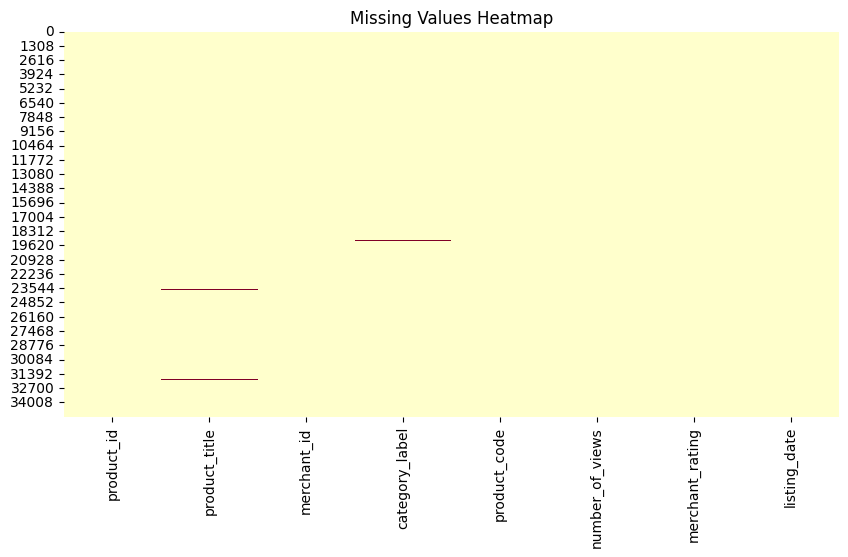

In [75]:
# Visualize missing data with seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

Merchant rating distribution analysis

-understand the balance between classes

-detect if the dataset is skewed

In [76]:
# Count occurrences of each sentiment label
merchant_rating_counts = df['merchant_rating'].value_counts()

# Print counts
print("Merchant Rating distribution (counts):")
print(merchant_rating_counts)

Merchant Rating distribution (counts):
merchant_rating
2.6    938
3.0    932
1.4    918
1.9    917
4.6    915
3.4    913
3.6    911
2.3    906
1.3    905
4.3    899
2.4    895
3.9    894
1.7    893
3.7    892
1.2    891
3.5    888
3.8    888
2.7    881
3.3    880
3.2    874
4.9    872
4.8    871
4.4    869
3.1    864
2.2    864
2.1    859
1.8    858
2.0    857
2.5    857
1.1    855
4.1    855
4.0    854
4.7    849
4.2    849
2.9    847
2.8    846
1.5    844
1.6    842
4.5    832
5.0    442
1.0    425
Name: count, dtype: int64


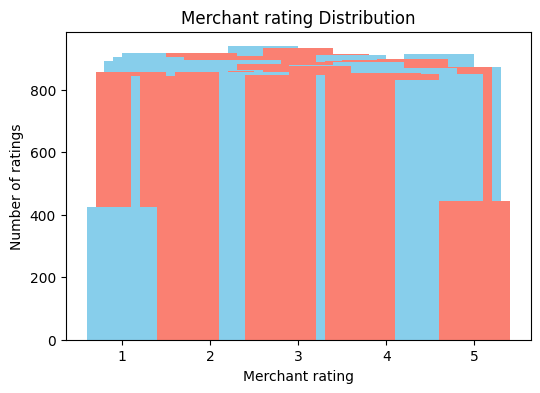

In [77]:
# Plot merchant rating distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(merchant_rating_counts.index, merchant_rating_counts.values, color=['skyblue', 'salmon'])
plt.title("Merchant rating Distribution")
plt.xlabel("Merchant rating")
plt.ylabel("Number of ratings")
plt.show()

## Exploring the 'Category Label' column

-check the data typeof the 'Category Label' column,

-preview a few sample values,

-identify the most common category labels,

-detect problematic values such as '"Free"', '"N/A"' or

corrupted symbols.

In [81]:
from numpy._core import numeric

# Codul trebuie modificat la titlurile coloanelor cu _  intre cuvinte
# 1. Check the data type of the 'Category Label' column
print("Data type of category label column:", df['category_label'].dtype)


# # 2. Display the first 10 values from the column
print("\nFirst 10 values in category_label column:")
print(df['category_label'].head(100))

# # 3. Show the 20 most frequent values in the column
print("\nTop 20 most frequent values in category_label column:")
print(df['category_label'].value_counts().head(20))
print()

# # 4. Check for unknown text values
problematic_values = ['Free', 'Not Available', 'N/A', 'None', '-', 'free', 'unknown', 'Unavailable']
# # Identify rows containing these specific non-numeric values
mask_problematic = df['category_label'].astype(str).str.strip().isin(problematic_values)
df_problematic = df[mask_problematic]
print(f"\nFound {len(df_problematic)} rows with problematic textual values:")
display(df_problematic[['category_label']].drop_duplicates())

# # 5. Find and display some of the non-text values
invalid_category_label = df[df["category_label"].apply(lambda x: not isinstance(x, str))]

print("Number of non-text category labels: ",len(invalid_category_label))

print("Invalid texts: ",invalid_category_label[["category_label"]].drop_duplicates().head())

Data type of category label column: object

First 10 values in category_label column:
0     Mobile Phones
1     Mobile Phones
2     Mobile Phones
3     Mobile Phones
4     Mobile Phones
          ...      
95    Mobile Phones
96    Mobile Phones
97    Mobile Phones
98    Mobile Phones
99    Mobile Phones
Name: category_label, Length: 100, dtype: object

Top 20 most frequent values in category_label column:
category_label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


Found 0 rows with problematic textual values:


,category_label


Number of non-text category labels:  44
Invalid texts:      category_label
162            NaN
